# Compute and plot the angle of the velocities with respect to that of the slope

θ = arccos( ( u · v ) / ( ||u|| * ||v|| ) )

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cmocean as cm
import xgcm
import colorcet as cct

In [2]:
from dask.distributed import Client

In [3]:
c = Client()
c 

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43469 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:43469/status,
Dashboard: http://127.0.0.1:43469/status,Workers: 8
Total threads: 48,Total memory: 503.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44124,Workers: 0
Dashboard: http://127.0.0.1:43469/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45029,Total threads: 6
Dashboard: http://127.0.0.1:44211/status,Memory: 62.90 GiB
Nanny: tcp://127.0.0.1:42324,


# Load data

In [4]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

In [5]:
from xmitgcm import open_mdsdataset

In [6]:
c="80m"
td="2"

In [7]:
ds_dz2 = open_mdsdataset(input_data+"run_z512_dz2/c{0}_Td{1}_vshift48".format(c,td),delta_t=4,prefix=['vels', 'state2D', 'scalars'])
ds_dz4 = open_mdsdataset(input_data+"run_z512_dz4/c{0}_Td{1}_vshift24".format(c,td),delta_t=4,prefix=['vels', 'state2D', 'scalars'])
# ds_dz2 = ds_dz4
ds_dz8 = open_mdsdataset(input_data+"run_z512_dz8/c{0}_Td{1}_vshift12".format(c,td),delta_t=4,prefix=['vels', 'state2D', 'scalars'])

In [8]:
ds_dz4=ds_dz4.sel(time=ds_dz2.time)
ds_dz8=ds_dz8.sel(time=ds_dz2.time)

In [9]:
# ds_dz2.time
2052000/(3600*24)

23.75

In [10]:
grid_dz2 = xgcm.Grid(ds_dz2, periodic=['X', 'Y'])
grid_dz4 = xgcm.Grid(ds_dz4, periodic=['X', 'Y'])
grid_dz8 = xgcm.Grid(ds_dz8, periodic=['X', 'Y'])

In [11]:
from utils import shifted_computations
from plot_utils import *

In [12]:
def shift_uv(ds,grid,sslice=slice(None,None),method="du"):
    u = ds.UVEL * ds.hFacW
    v = ds.VVEL * ds.hFacS
    shift_u =shifted_computations(u,method=method)#.mean("XC")
    shift_v =shifted_computations(v,method=method)#.mean("XC")
    
    interp_u = grid.interp( shift_u,'X').isel(YC=sslice)
    interp_v = grid.interp( shift_v,'Y').isel(YC=sslice)
    
    return interp_u,interp_v

In [13]:
u_dz2, v_dz2 = shift_uv(ds_dz2,grid_dz2)
u_dz4, v_dz4 = shift_uv(ds_dz4,grid_dz4)
u_dz8, v_dz8 = shift_uv(ds_dz8,grid_dz8)

In [14]:
u_dz2_ud, v_dz2_ud = shift_uv(ds_dz2,grid_dz2,method="ud")
u_dz4_ud, v_dz4_ud = shift_uv(ds_dz4,grid_dz4,method="ud")
u_dz8_ud, v_dz8_ud = shift_uv(ds_dz8,grid_dz8,method="ud")

In [15]:
RHOAnoma_dz2 = ds_dz2.RHOAnoma.where(ds_dz2.RHOAnoma>-25)
RHOAnoma_dz4 = ds_dz4.RHOAnoma.where(ds_dz4.RHOAnoma>-25)
RHOAnoma_dz8 = ds_dz8.RHOAnoma.where(ds_dz8.RHOAnoma>-25)

In [16]:

g=9.81
rho_0 = 1026

def compute_N2(ds,grid,var='RHOAnoma',dz=2):
    data = ds
    # try:
    drho_dz = grid.diff(data, "Z", boundary='extend')/dz
    N2 = g/rho_0 * drho_dz.rename({"Zl":"Z"})
    
    return N2

In [17]:
N2_dz2 = compute_N2(RHOAnoma_dz2,grid_dz2,dz=2)
N2_dz4 = compute_N2(RHOAnoma_dz4,grid_dz4,dz=4)
N2_dz8 = compute_N2(RHOAnoma_dz8,grid_dz8,dz=8)

In [18]:
N2_shifted_dz2 =shifted_computations(N2_dz2 ,method="du").mean("XC")
N2_shifted_dz4 =shifted_computations(N2_dz4 ,method="du").mean("XC")
N2_shifted_dz8 =shifted_computations(N2_dz8 ,method="du").mean("XC")

N2_shifted_ud_dz2 =shifted_computations(N2_dz2 ,method="ud").mean("XC")
N2_shifted_ud_dz4 =shifted_computations(N2_dz4 ,method="ud").mean("XC")
N2_shifted_ud_dz8 =shifted_computations(N2_dz8 ,method="ud").mean("XC")

In [19]:
N2_shifted_dz2["Z"] = N2_shifted_dz2["Z"] + 512
N2_shifted_dz4["Z"] = N2_shifted_dz4["Z"] + 512
N2_shifted_dz8["Z"] = N2_shifted_dz8["Z"] + 512

N2_shifted_dz2["YC"] = N2_shifted_dz2["YC"]/1000
N2_shifted_dz4["YC"] = N2_shifted_dz4["YC"]/1000
N2_shifted_dz8["YC"] = N2_shifted_dz8["YC"]/1000

N2_shifted_ud_dz2["Z"] = N2_shifted_ud_dz2["Z"] 
N2_shifted_ud_dz4["Z"] = N2_shifted_ud_dz4["Z"] 
N2_shifted_ud_dz8["Z"] = N2_shifted_ud_dz8["Z"] 

N2_shifted_ud_dz2["YC"] = N2_shifted_ud_dz2["YC"]/1000
N2_shifted_ud_dz4["YC"] = N2_shifted_ud_dz4["YC"]/1000
N2_shifted_ud_dz8["YC"] = N2_shifted_ud_dz8["YC"]/1000

In [20]:
rhoA_dz2 =shifted_computations(RHOAnoma_dz2 ,method="du").mean("XC")
rhoA_dz4 =shifted_computations(RHOAnoma_dz4 ,method="du").mean("XC")
rhoA_dz8 =shifted_computations(RHOAnoma_dz8 ,method="du").mean("XC")

In [21]:
rhoA_dz2["Z"] = rhoA_dz2["Z"] + 512
rhoA_dz4["Z"] = rhoA_dz4["Z"] + 512
rhoA_dz8["Z"] = rhoA_dz8["Z"] + 512

rhoA_dz2["YC"] = rhoA_dz2["YC"]/1000
rhoA_dz4["YC"] = rhoA_dz4["YC"]/1000
rhoA_dz8["YC"] = rhoA_dz8["YC"]/1000

In [22]:
theta_dz2 = (np.degrees(np.arctan2(v_dz2, u_dz2)))
theta_dz2 = theta_dz2.mean("XC")

theta_dz4 = (np.degrees(np.arctan2(v_dz4, u_dz4)))
theta_dz4 = theta_dz4.mean("XC")

theta_dz8 = (np.degrees(np.arctan2(v_dz8, u_dz8)))
theta_dz8 = theta_dz8.mean("XC")

In [23]:
theta_dz2["Z"] = theta_dz2["Z"] + 512
theta_dz4["Z"] = theta_dz4["Z"] + 512
theta_dz8["Z"] = theta_dz8["Z"] + 512

In [24]:
theta_dz2["YC"] = theta_dz2["YC"]/1000
theta_dz4["YC"] = theta_dz4["YC"]/1000
theta_dz8["YC"] = theta_dz8["YC"]/1000

In [25]:
u_dz2["Z"] = u_dz2["Z"] + 512
u_dz4["Z"] = u_dz4["Z"] + 512
u_dz8["Z"] = u_dz8["Z"] + 512

u_dz2["YC"] = u_dz2["YC"]/1000
u_dz4["YC"] = u_dz4["YC"]/1000
u_dz8["YC"] = u_dz8["YC"]/1000

v_dz2["Z"] = v_dz2["Z"] + 512
v_dz4["Z"] = v_dz4["Z"] + 512
v_dz8["Z"] = v_dz8["Z"] + 512

v_dz2["YC"] = v_dz2["YC"]/1000
v_dz4["YC"] = v_dz4["YC"]/1000
v_dz8["YC"] = v_dz8["YC"]/1000

In [26]:
u_dz2_ud["Z"] = u_dz2_ud["Z"] 
u_dz4_ud["Z"] = u_dz4_ud["Z"] 
u_dz8_ud["Z"] = u_dz8_ud["Z"] 

u_dz2_ud["YC"] = u_dz2_ud["YC"]/1000
u_dz4_ud["YC"] = u_dz4_ud["YC"]/1000
u_dz8_ud["YC"] = u_dz8_ud["YC"]/1000

v_dz2_ud["Z"] = v_dz2_ud["Z"] 
v_dz4_ud["Z"] = v_dz4_ud["Z"] 
v_dz8_ud["Z"] = v_dz8_ud["Z"] 

v_dz2_ud["YC"] = v_dz2_ud["YC"]/1000
v_dz4_ud["YC"] = v_dz4_ud["YC"]/1000
v_dz8_ud["YC"] = v_dz8_ud["YC"]/1000

In [27]:
mag_dz2 = v_dz2**2 + u_dz2**2
mag_dz2 = mag_dz2.mean("XC")

mag_dz4 = v_dz4**2 + u_dz4**2
mag_dz4 = mag_dz4.mean("XC")

mag_dz8 = v_dz8**2 + u_dz8**2
mag_dz8 = mag_dz8.mean("XC")

In [28]:
w_dz2 = shifted_computations(ds_dz2.WVEL,method="du",dims=['Zl'])
w_dz4 = shifted_computations(ds_dz4.WVEL,method="du",dims=['Zl'])
w_dz8 = shifted_computations(ds_dz8.WVEL,method="du",dims=['Zl'])

In [29]:
w_dz2["Zl"] = w_dz2["Zl"] + 512
w_dz4["Zl"] = w_dz4["Zl"] + 512
w_dz8["Zl"] = w_dz8["Zl"] + 512

w_dz2["YC"] = w_dz2["YC"]/1000
w_dz4["YC"] = w_dz4["YC"]/1000
w_dz8["YC"] = w_dz8["YC"]/1000

In [30]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

In [31]:
def add_windrose(vec_ax,vmin=-180,vmax=180,cmap=cct.cm.CET_C1s):
    x1, x2, y1, y2 = -1,1,-1,1
    vec_ax.set_xlim(x1, x2)
    vec_ax.set_ylim(y1, y2)
    vec_ax.set_aspect('equal', 'box')
    
    u = np.array([1,0.5,0,-0.5,-1,-0.5,0,-1,0.5])
    v = np.array([0,0.5,1,0.5,0,-0.5,-1,0,-0.5])
    x=np.zeros(len(u))
    color = np.degrees(np.arctan2(v,u))
    color[color<vmin]=vmin
    color[color>vmax]=vmax
    
    vec_ax.quiver(x,x,u,v,color,cmap=cmap,scale=2,width=0.05)
    vec_ax.text(1,0,r"0$^\circ$",fontsize=6,horizontalalignment='left')
    vec_ax.text(0,1,r"90$^\circ$",fontsize=6,horizontalalignment='center')
    vec_ax.text(-1,0,r"180$^\circ$",fontsize=6,horizontalalignment='right')
    vec_ax.text(0,-1,r"270$^\circ$",fontsize=6,horizontalalignment='center',verticalalignment='top')
    vec_ax.set_axis_off()

def plot_hfacc_surf_shifted(ax,ds,dz,z_shift=512):
    
    x_ = (ds.YC - 60/2)/1000
    x_ = np.append(np.roll(np.repeat(x_, 2),-1)[:-1], x_[-1])
    Hfacc_shifted = shifted_computations(ds.hFacC,method="du").isel(XC=0).T

    z_ = abs((np.max(np.cumsum( Hfacc_shifted ,axis=0),axis=0) ) * - dz) 
    z_ = np.repeat(z_, 2) 

    x = np.append(np.hstack((0 ,x_)),x_[-1]+60/2000)
    
    z = np.append(np.hstack((z_shift ,z_)),z_shift)

    verts = [np.array(list(zip(x, z)))]
    # print(verts)
    
    poly = PolyCollection(verts, alpha=1, zorder=1,
                          facecolors=[[0.9, 0.9, 0.9]])
    ax.add_collection(poly)

In [32]:
import matplotlib.colors as mcolors
colors2 = cct.cm.coolwarm(np.linspace(0.5, 1, 128))
colors1 = cct.cm.coolwarm(np.linspace(0, 0.5, int(128/10)))

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
# mymap = cct.cm.coolwarm

In [33]:
melt_min,melt_max=40,100

# melt_min,melt_max=0,1

In [34]:
seconds_per_year=365*24*3600    
M_dz2 = -((ds_dz2.SHIfwFlx* seconds_per_year)/1030 ).isel(time=-1).mean().compute()
M_dz4 = -((ds_dz4.SHIfwFlx* seconds_per_year)/1030 ).isel(time=-1).mean().compute()
M_dz8 = -((ds_dz8.SHIfwFlx* seconds_per_year)/1030 ).isel(time=-1).mean().compute()

In [35]:
print("Averaged meltrates for 80m channel:") 
print("dz 2 =", M_dz2.values)
print("dz 4 =", M_dz4.values)
print("dz 8 =", M_dz8.values)

Averaged meltrates for 80m channel:
dz 2 = 44.31592
dz 4 = 58.237892
dz 8 = 69.25599


In [36]:
M_dz2 = -((ds_dz2.SHIfwFlx* seconds_per_year)/1030 ).isel(time=-1).mean("XC").compute()
M_dz4 = -((ds_dz4.SHIfwFlx* seconds_per_year)/1030 ).isel(time=-1).mean("XC").compute()
M_dz8 = -((ds_dz8.SHIfwFlx* seconds_per_year)/1030 ).isel(time=-1).mean("XC").compute()

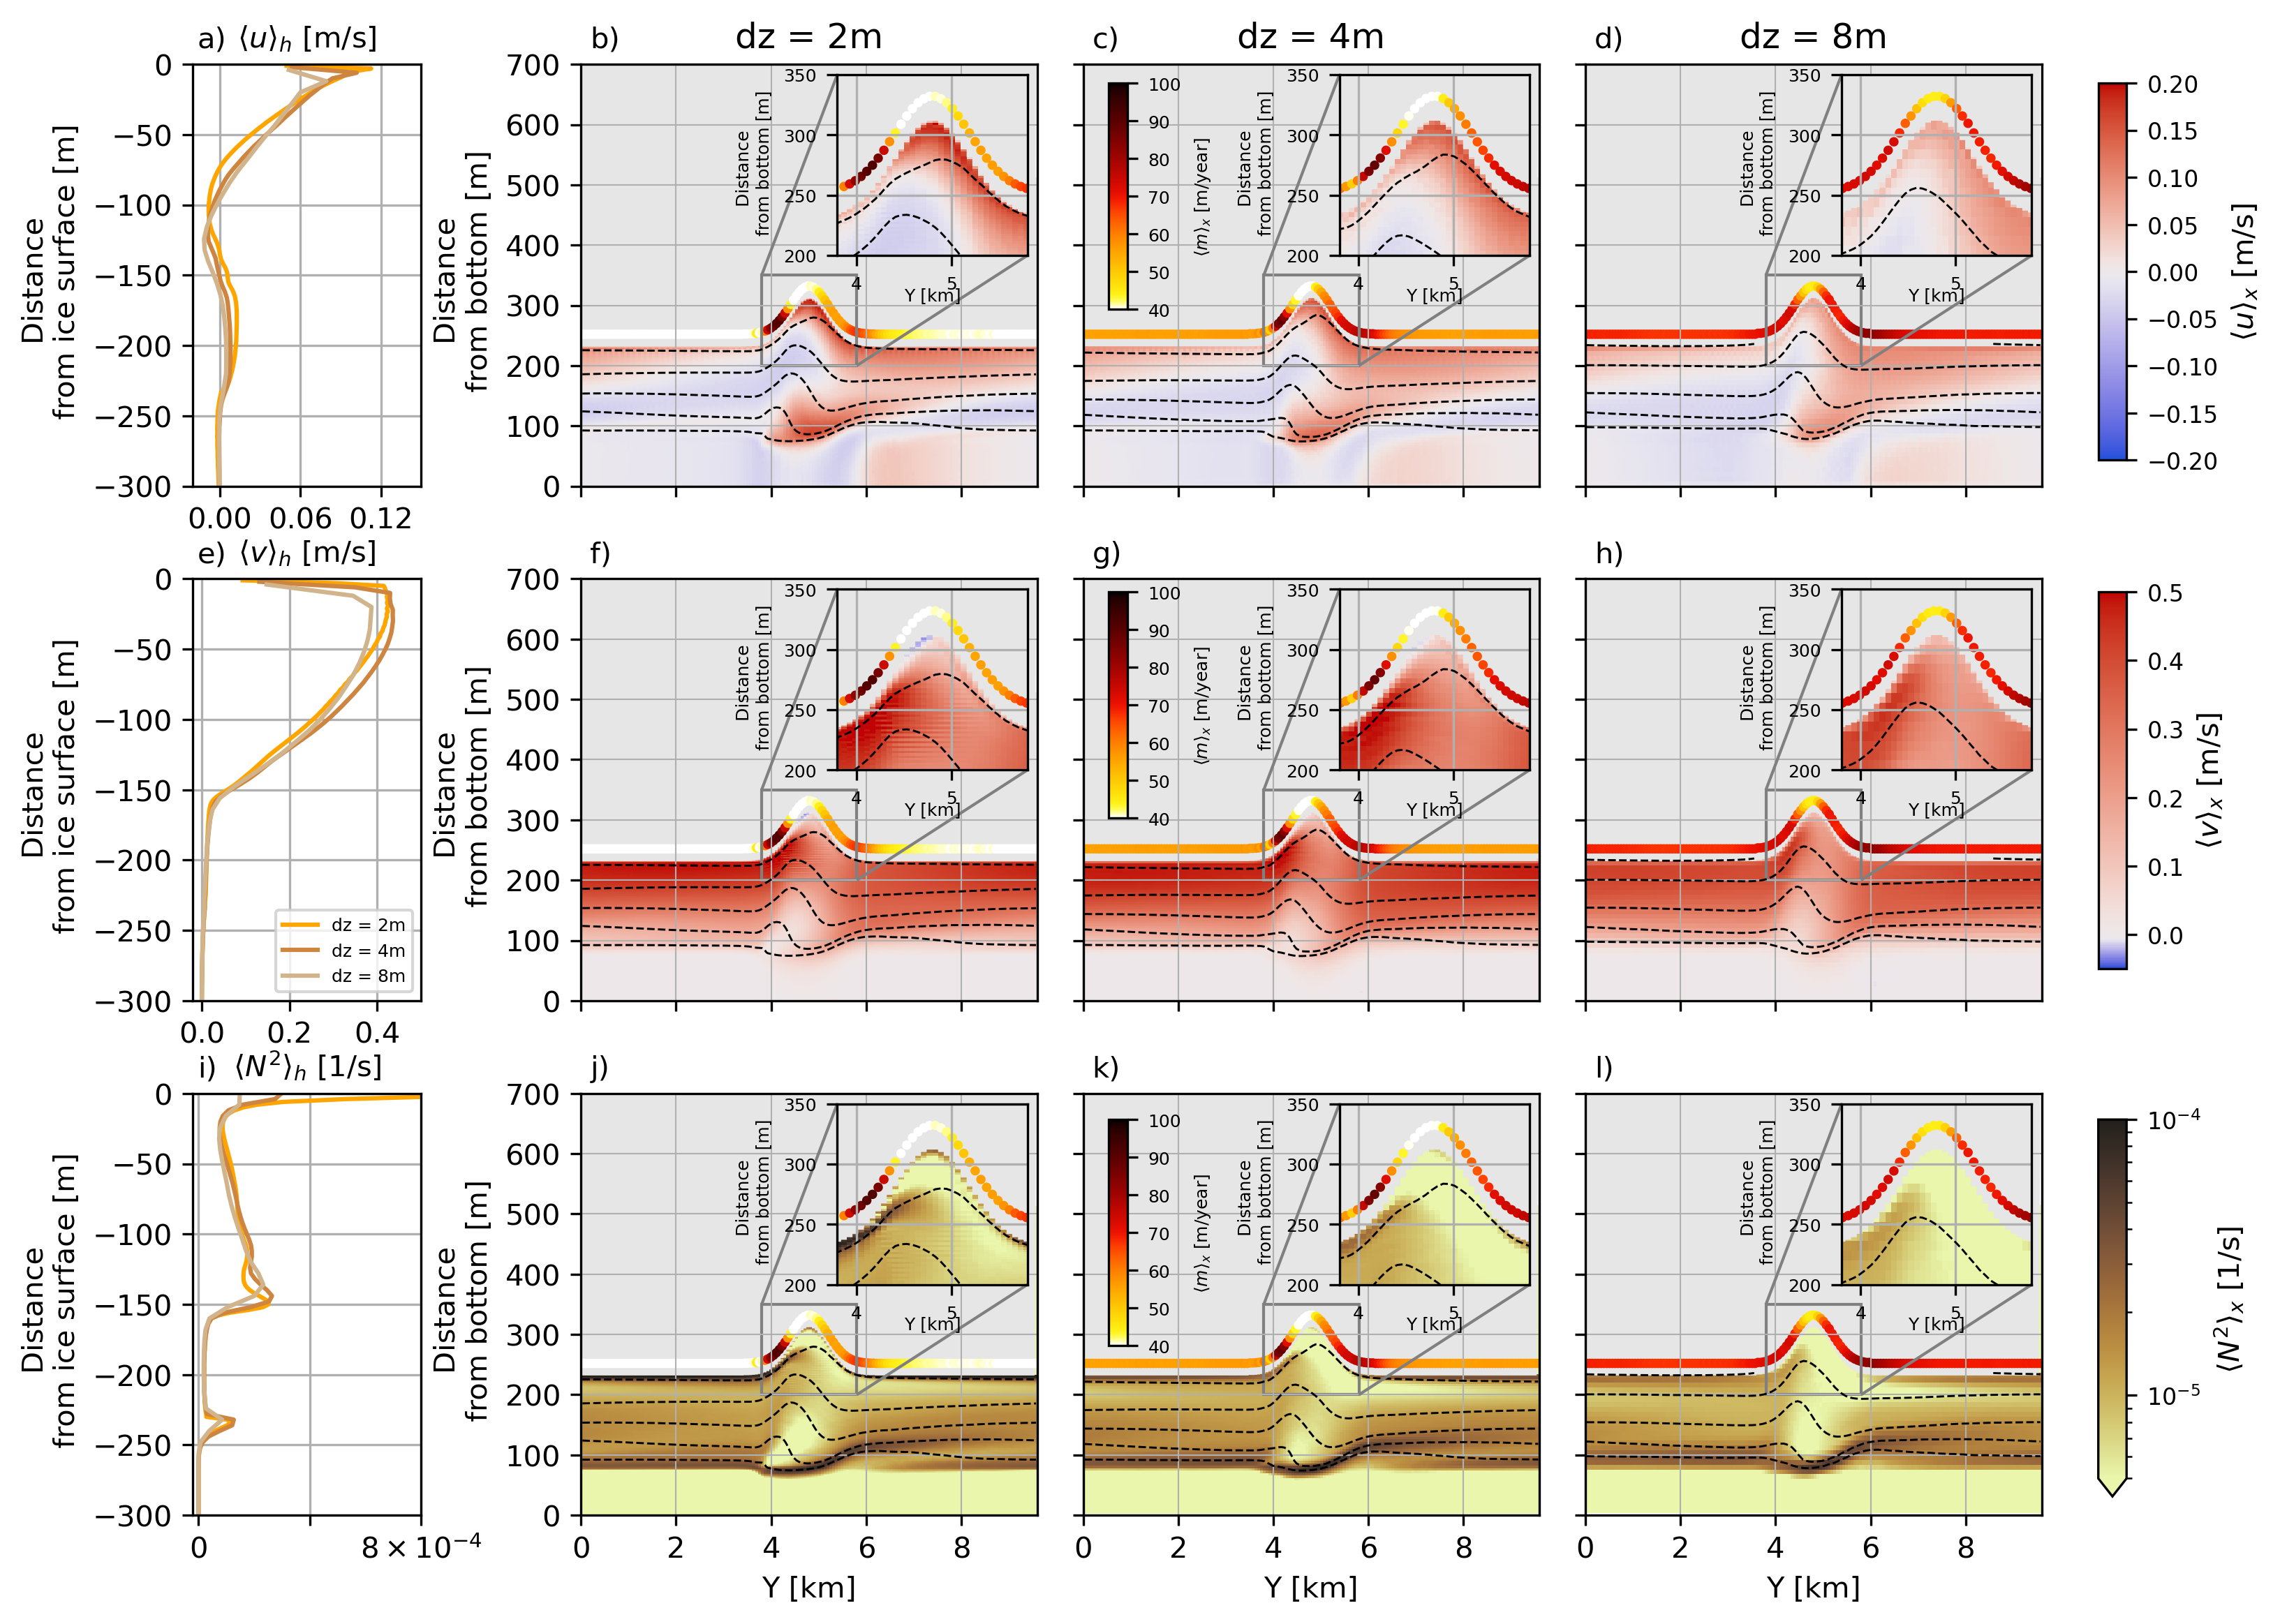

In [37]:
import matplotlib.ticker as ticker

fig,axs = plt.subplots(3,3,figsize=(9,9),dpi=300,sharey=True,sharex=True)

########### ###### ############
########### PLOT U ############
########### ###### ############

val_range = 0.2

ax=axs[0,:]
# melt_min,melt_max=0,1.5

cbar = u_dz2.mean("XC").isel(time=-1).plot(ax=ax[0], x="YC",cmap=cct.cm.coolwarm, add_colorbar=False,rasterized=True,vmin=-val_range,vmax=val_range )
u_dz4.mean("XC").isel(time=-1).plot(ax=ax[1], x="YC",cmap=cct.cm.coolwarm, add_colorbar=False,rasterized=True,vmin=-val_range,vmax=val_range )
u_dz8.mean("XC").isel(time=-1).plot(ax=ax[2], x="YC",cmap=cct.cm.coolwarm, add_colorbar=False,rasterized=True,vmin=-val_range,vmax=val_range )

cbar_ax = fig.add_axes([0.93, 0.67, 0.015, 0.2])
fig.colorbar(cbar, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<u\right>_x$ [m/s]",fontsize=10)
cbar_ax.yaxis.set_tick_params(labelsize=8)

plot_hfacc_surf_shifted(ax[0],ds_dz2,2,z_shift=700)
plot_hfacc_surf_shifted(ax[1],ds_dz4,4,z_shift=700)
plot_hfacc_surf_shifted(ax[2],ds_dz8,8,z_shift=700)

cbar_m = plot_meltrates(ax[0],ds_dz2,dz=2,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(ax[1],ds_dz4,dz=4,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(ax[2],ds_dz8,dz=8,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)

cbar_ax = fig.add_axes([0.405, 0.75, 0.01, 0.12])
fig.colorbar(cbar_m, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<m\right>_x$ [m/year]",fontsize=6)
cbar_ax.yaxis.set_tick_params(labelsize=6)

rhoA_dz2.isel(time=-1).plot.contour(ax=ax[0],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))
rhoA_dz4.isel(time=-1).plot.contour(ax=ax[1],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))
rhoA_dz8.isel(time=-1).plot.contour(ax=ax[2],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

ax[0].text(0.02, 1.04, "b)", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.02, 1.04, "c)", fontsize=10, transform=ax[1].transAxes)
ax[2].text(0.02, 1.04, "d)", fontsize=10, transform=ax[2].transAxes)

ax[0].set_title("dz = 2m")
ax[1].set_title("dz = 4m")
ax[2].set_title("dz = 8m")

[a.set_xlabel("") for a in ax]
[a.set_ylabel("") for a in ax]
# [a.set_title("") for a in ax]
[a.grid(linewidth=0.5) for a in ax]

ax[0].set_ylabel("Distance \n from bottom [m]") 

###################################

axins1 = zoomed_inset_axes(ax[0], 2, bbox_to_anchor=[0.21,0.01,0.8,1], bbox_transform=ax[0].transAxes)

cbar1 = u_dz2.mean("XC").isel(time=-1).plot(ax=axins1, x="YC",cmap=cct.cm.coolwarm, add_colorbar=False,rasterized=True,vmin=-val_range,vmax=val_range )

rhoA_dz2.isel(time=-1).plot.contour(ax=axins1,x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

x1, x2, y1, y2 = 3.8,5.8,200,350
axins1.set_xlim(x1, x2)
axins1.set_ylim(y1, y2)


# plot_hfacc_surf_2D(vert_top_dz4,vert_bottom_dz4,ax=axins1,
#                    key="Y",grid=np.array((60/1000,60/1000,-4)))

###################################

axins2 = zoomed_inset_axes(ax[1], 2, bbox_to_anchor=[0.21,0.01,0.8,1], bbox_transform=ax[1].transAxes)

cbar1 = u_dz4.mean("XC").isel(time=-1).plot(ax=axins2, x="YC",cmap=cct.cm.coolwarm, add_colorbar=False,rasterized=True,vmin=-val_range,vmax=val_range )

rhoA_dz4.isel(time=-1).plot.contour(ax=axins2,x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

x1, x2, y1, y2 = 3.8,5.8,200,350
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

# ###################################

axins3 = zoomed_inset_axes(ax[2], 2, bbox_to_anchor=[0.21,0.01,0.8,1], bbox_transform=ax[2].transAxes)

u_dz8.mean("XC").isel(time=-1).plot(ax=axins3, x="YC",cmap=cct.cm.coolwarm, add_colorbar=False,rasterized=True,vmin=-val_range,vmax=val_range )

rhoA_dz8.isel(time=-1).plot.contour(ax=axins3,x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

plot_hfacc_surf_shifted(axins1,ds_dz2,2)
plot_hfacc_surf_shifted(axins2,ds_dz4,4)
plot_hfacc_surf_shifted(axins3,ds_dz8,8)

plot_meltrates(axins1,ds_dz2,dz=2,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(axins2,ds_dz4,dz=4,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(axins3,ds_dz8,dz=8,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)

x1, x2, y1, y2 = 3.8,5.8,200,350
axins3.set_xlim(x1, x2)
axins3.set_ylim(y1, y2)

mark_inset(ax[0], axins1, loc1=2, loc2=4, fc="none", ec="0.5")
mark_inset(ax[1], axins2, loc1=2, loc2=4, fc="none", ec="0.5")
mark_inset(ax[2], axins3, loc1=2, loc2=4, fc="none", ec="0.5")


[a.set_xlabel("Y [km]",labelpad=-2) for a in [axins1,axins2,axins3]]
[a.set_title("") for a in [axins1,axins2,axins3]]
[a.xaxis.label.set_size(6) for a in [axins1,axins2,axins3]]
[a.yaxis.label.set_size(6) for a in [axins1,axins2,axins3]]
[a.xaxis.set_tick_params(labelsize=6) for a in [axins1,axins2,axins3]]
[a.yaxis.set_tick_params(labelsize=6) for a in [axins1,axins2,axins3]]
[a.grid() for a in [axins1,axins2,axins3]]

[a.set_ylabel("Distance \n from bottom [m]") for a in [axins1,axins2,axins3]]

ax[0].set_ylim(0,700)

########### ###### ############
########### PLOT V ############
########### ###### ############

ax=axs[1,:]

vel_min,vel_max=-0.05,0.5
# vel_min,vel_max=-0.05,0.05

cbar = v_dz2.mean("XC").isel(time=-1).plot(ax=ax[0], x="YC",cmap=mymap, add_colorbar=False,rasterized=True, vmin=vel_min,vmax=vel_max )
v_dz4.mean("XC").isel(time=-1).plot(ax=ax[1], x="YC",cmap=mymap, add_colorbar=False,rasterized=True, vmin=vel_min,vmax=vel_max )
v_dz8.mean("XC").isel(time=-1).plot(ax=ax[2], x="YC",cmap=mymap, add_colorbar=False,rasterized=True, vmin=vel_min,vmax=vel_max )


rhoA_dz2.isel(time=-1).plot.contour(ax=ax[0],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))
rhoA_dz4.isel(time=-1).plot.contour(ax=ax[1],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))
rhoA_dz8.isel(time=-1).plot.contour(ax=ax[2],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

cbar_ax = fig.add_axes([0.93, 0.40, 0.015, 0.2])
fig.colorbar(cbar, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<v\right>_x$ [m/s]",fontsize=10)
cbar_ax.yaxis.set_tick_params(labelsize=8)

plot_hfacc_surf_shifted(ax[0],ds_dz2,2,z_shift=700)
plot_hfacc_surf_shifted(ax[1],ds_dz4,4,z_shift=700)
plot_hfacc_surf_shifted(ax[2],ds_dz8,8,z_shift=700)

cbar_m = plot_meltrates(ax[0],ds_dz2,dz=2,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(ax[1],ds_dz4,dz=4,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(ax[2],ds_dz8,dz=8,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)

cbar_ax = fig.add_axes([0.405, 0.48, 0.01, 0.12])
fig.colorbar(cbar_m, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<m\right>_x$ [m/year]",fontsize=6)
cbar_ax.yaxis.set_tick_params(labelsize=6)

ax[0].text(0.02, 1.04, "f)", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.02, 1.04, "g)", fontsize=10, transform=ax[1].transAxes)
ax[2].text(0.02, 1.04, "h)", fontsize=10, transform=ax[2].transAxes)

[a.set_xlabel("") for a in ax]
[a.set_ylabel("") for a in ax]
[a.set_title("") for a in ax]
[a.grid(linewidth=0.5) for a in ax]

ax[0].set_ylabel("Distance \n from bottom [m]") 

###################################

axins1 = zoomed_inset_axes(ax[0], 2, bbox_to_anchor=[0.21,0.01,0.8,1], bbox_transform=ax[0].transAxes)

cbar1 = v_dz2.mean("XC").isel(time=-1).plot(ax=axins1, x="YC",cmap=mymap, add_colorbar=False,rasterized=True,vmin=vel_min,vmax=vel_max )

rhoA_dz2.isel(time=-1).plot.contour(ax=axins1,x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

x1, x2, y1, y2 = 3.8,5.8,200,350
axins1.set_xlim(x1, x2)
axins1.set_ylim(y1, y2)

###################################

axins2 = zoomed_inset_axes(ax[1], 2, bbox_to_anchor=[0.21,0.01,0.8,1], bbox_transform=ax[1].transAxes)

v_dz4.mean("XC").isel(time=-1).plot(ax=axins2, x="YC",cmap=mymap, add_colorbar=False,rasterized=True,vmin=vel_min,vmax=vel_max )

rhoA_dz4.isel(time=-1).plot.contour(ax=axins2,x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

x1, x2, y1, y2 = 3.8,5.8,200,350
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

###################################

axins3 = zoomed_inset_axes(ax[2], 2, bbox_to_anchor=[0.21,0.01,0.8,1], bbox_transform=ax[2].transAxes)

v_dz8.mean("XC").isel(time=-1).plot(ax=axins3, x="YC",cmap=mymap, add_colorbar=False,rasterized=True,vmin=vel_min,vmax=vel_max )

rhoA_dz8.isel(time=-1).where(rhoA_dz8.isel(time=-1)!=0).plot.contour(ax=axins3,x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

x1, x2, y1, y2 = 3.8,5.8,200,350
axins3.set_xlim(x1, x2)
axins3.set_ylim(y1, y2)

plot_hfacc_surf_shifted(axins1,ds_dz2,2)
plot_hfacc_surf_shifted(axins2,ds_dz4,4)
plot_hfacc_surf_shifted(axins3,ds_dz8,8)

plot_meltrates(axins1,ds_dz2,dz=2,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(axins2,ds_dz4,dz=4,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(axins3,ds_dz8,dz=8,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)

mark_inset(ax[0], axins1, loc1=2, loc2=4, fc="none", ec="0.5")
mark_inset(ax[1], axins2, loc1=2, loc2=4, fc="none", ec="0.5")
mark_inset(ax[2], axins3, loc1=2, loc2=4, fc="none", ec="0.5")


[a.set_xlabel("Y [km]",labelpad=-2) for a in [axins1,axins2,axins3]]
[a.set_title("") for a in [axins1,axins2,axins3]]
[a.xaxis.label.set_size(6) for a in [axins1,axins2,axins3]]
[a.yaxis.label.set_size(6) for a in [axins1,axins2,axins3]]
[a.xaxis.set_tick_params(labelsize=6) for a in [axins1,axins2,axins3]]
[a.yaxis.set_tick_params(labelsize=6) for a in [axins1,axins2,axins3]]
[a.grid() for a in [axins1,axins2,axins3]]

[a.set_ylabel("Distance \n from bottom [m]") for a in [axins1,axins2,axins3]]

ax[0].set_ylim(0,700)

########### ###### ############
########### PLOT N2 ############
########### ###### ############

ax=axs[2,:]

N2_min,N2_max=0.5e-5,1e-4
# vel_min,vel_max=-0.05,0.05

cbar = N2_shifted_dz2.isel(time=-1).plot(ax=ax[0], x="YC",cmap=cm.cm.turbid, add_colorbar=False,rasterized=True, vmin=N2_min,vmax=N2_max,norm=mcolors.LogNorm(),extend="min" )
cbar_1 = N2_shifted_dz4.isel(time=-1).plot(ax=ax[1], x="YC",cmap=cm.cm.turbid, add_colorbar=False,rasterized=True, vmin=N2_min,vmax=N2_max,norm=mcolors.LogNorm(),extend="min")
cbar_2 = N2_shifted_dz8.isel(time=-1).plot(ax=ax[2], x="YC",cmap=cm.cm.turbid, add_colorbar=False,rasterized=True, vmin=N2_min,vmax=N2_max,norm=mcolors.LogNorm(),extend="min" )

rhoA_dz2.isel(time=-1).plot.contour(ax=ax[0],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))
rhoA_dz4.isel(time=-1).plot.contour(ax=ax[1],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))
rhoA_dz8.isel(time=-1).plot.contour(ax=ax[2],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

cbar_ax = fig.add_axes([0.93, 0.12, 0.015, 0.2])
fig.colorbar(cbar, cax =cbar_ax,extend="min")
cbar_ax.set_ylabel(r"$\left<N^2\right>_x$ [1/s]",fontsize=10)
cbar_ax.yaxis.set_tick_params(labelsize=8)

plot_hfacc_surf_shifted(ax[0],ds_dz2,2,z_shift=700)
plot_hfacc_surf_shifted(ax[1],ds_dz4,4,z_shift=700)
plot_hfacc_surf_shifted(ax[2],ds_dz8,8,z_shift=700)

cbar_m = plot_meltrates(ax[0],ds_dz2,dz=2,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(ax[1],ds_dz4,dz=4,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(ax[2],ds_dz8,dz=8,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)

cbar_ax = fig.add_axes([0.405, 0.2, 0.01, 0.12])
fig.colorbar(cbar_m, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<m\right>_x$ [m/year]",fontsize=6)
cbar_ax.yaxis.set_tick_params(labelsize=6)

ax[0].text(0.02, 1.04, "j)", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.02, 1.04, "k)", fontsize=10, transform=ax[1].transAxes)
ax[2].text(0.02, 1.04, "l)", fontsize=10, transform=ax[2].transAxes)

[a.set_xlabel("Y [km]") for a in ax]
[a.set_ylabel("") for a in ax]
[a.set_title("") for a in ax]
[a.grid(linewidth=0.5) for a in ax]

ax[0].set_ylabel("Distance \n from bottom [m]") 

###################################

axins1 = zoomed_inset_axes(ax[0], 2, bbox_to_anchor=[0.21,0.01,0.8,1], bbox_transform=ax[0].transAxes)

cbar1 = N2_shifted_dz2.isel(time=-1).plot(ax=axins1, x="YC",cmap=cm.cm.turbid, add_colorbar=False,rasterized=True,vmin=N2_min,vmax=N2_max,norm=mcolors.LogNorm(),extend="min")

rhoA_dz2.isel(time=-1).plot.contour(ax=axins1,x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

x1, x2, y1, y2 = 3.8,5.8,200,350
axins1.set_xlim(x1, x2)
axins1.set_ylim(y1, y2)

###################################

axins2 = zoomed_inset_axes(ax[1], 2, bbox_to_anchor=[0.21,0.01,0.8,1], bbox_transform=ax[1].transAxes)

N2_shifted_dz4.isel(time=-1).plot(ax=axins2, x="YC",cmap=cm.cm.turbid, add_colorbar=False,rasterized=True,vmin=N2_min,vmax=N2_max,norm=mcolors.LogNorm(),extend="min" )

rhoA_dz4.isel(time=-1).plot.contour(ax=axins2,x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

x1, x2, y1, y2 = 3.8,5.8,200,350
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

###################################

axins3 = zoomed_inset_axes(ax[2], 2, bbox_to_anchor=[0.21,0.01,0.8,1], bbox_transform=ax[2].transAxes)

N2_shifted_dz8.isel(time=-1).plot(ax=axins3, x="YC",cmap=cm.cm.turbid, add_colorbar=False,rasterized=True,vmin=N2_min,vmax=N2_max,norm=mcolors.LogNorm(),extend="min")

rhoA_dz8.isel(time=-1).where(rhoA_dz8.isel(time=-1)!=0).plot.contour(ax=axins3,x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

x1, x2, y1, y2 = 3.8,5.8,200,350
axins3.set_xlim(x1, x2)
axins3.set_ylim(y1, y2)

plot_hfacc_surf_shifted(axins1,ds_dz2,2)
plot_hfacc_surf_shifted(axins2,ds_dz4,4)
plot_hfacc_surf_shifted(axins3,ds_dz8,8)

plot_meltrates(axins1,ds_dz2,dz=2,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(axins2,ds_dz4,dz=4,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)
plot_meltrates(axins3,ds_dz8,dz=8,shift=20,s=5,cmap=cct.cm.fire_r,vmin=melt_min,vmax=melt_max)

mark_inset(ax[0], axins1, loc1=2, loc2=4, fc="none", ec="0.5")
mark_inset(ax[1], axins2, loc1=2, loc2=4, fc="none", ec="0.5")
mark_inset(ax[2], axins3, loc1=2, loc2=4, fc="none", ec="0.5")


[a.set_xlabel("Y [km]",labelpad=-2) for a in [axins1,axins2,axins3]]
[a.set_title("") for a in [axins1,axins2,axins3]]
[a.xaxis.label.set_size(6) for a in [axins1,axins2,axins3]]
[a.yaxis.label.set_size(6) for a in [axins1,axins2,axins3]]
[a.xaxis.set_tick_params(labelsize=6) for a in [axins1,axins2,axins3]]
[a.yaxis.set_tick_params(labelsize=6) for a in [axins1,axins2,axins3]]
[a.grid() for a in [axins1,axins2,axins3]]

[a.set_ylabel("Distance \n from bottom [m]") for a in [axins1,axins2,axins3]]

ax[0].set_ylim(0,700)

######### ################### ########
######### Insets U V profiles ########
######### ################### ########

iax1 = axs[0,0].inset_axes([-0.85, 0, .5, 1])
u_dz2_ud.isel(time=-1).mean(("XC","YC")).plot(ax=iax1,y="Z",color="orange",label="dz = 2m")
u_dz4_ud.isel(time=-1).mean(("XC","YC")).plot(ax=iax1,y="Z",color="Peru",label="dz = 4m")
u_dz8_ud.isel(time=-1).mean(("XC","YC")).plot(ax=iax1,y="Z",color="tan",label="dz = 8m")
# iax1.legend(fontsize=6,loc=4)
iax1.set_ylabel("Distance \n from ice surface [m]")
iax1.set_xlabel("")
# iax1.text(1, -0.1, "u [m/s]", fontsize=10, transform=iax1.transAxes)
iax1.set_title(r"$\left<u\right>_h$ [m/s]",fontsize=10)
iax1.set_ylim((-300,0))
# iax1.xaxis.set_visible(False)
# iax1.xaxis.set_ticklabels([])
iax1.set_xlim((-0.02,0.15))
iax1.text(0.02, 1.04, "a)", fontsize=10, transform=iax1.transAxes)
iax1.xaxis.set_major_locator(ticker.MaxNLocator(3))
iax1.grid()

iax2 = axs[1,0].inset_axes([-0.85, 0, .5, 1])
v_dz2_ud.isel(time=-1).mean(("XC","YC")).plot(ax=iax2,y="Z",color="orange",label="dz = 2m")
v_dz4_ud.isel(time=-1).mean(("XC","YC")).plot(ax=iax2,y="Z",color="Peru",label="dz = 4m")
v_dz8_ud.isel(time=-1).mean(("XC","YC")).plot(ax=iax2,y="Z",color="tan",label="dz = 8m")
iax2.legend(fontsize=6,loc=4)
iax2.set_ylabel("Distance \n from ice surface [m]")
iax2.set_xlabel("")
# iax2.text(1, -0.1, "v [m/s]", fontsize=10, transform=iax2.transAxes)
iax2.set_title(r"$\left<v\right>_h$ [m/s]",fontsize=10)
iax2.set_ylim((-300,0))
iax2.set_xlim((-0.02,0.5))
iax2.text(0.02, 1.04, "e)", fontsize=10, transform=iax2.transAxes)
iax2.xaxis.set_major_locator(ticker.MaxNLocator(3))
iax2.grid()

iax3 = axs[2,0].inset_axes([-0.85, 0, .5, 1])
N2_shifted_ud_dz2.isel(time=-1).mean(("YC")).plot(ax=iax3,y="Z",color="orange",label="dz = 2m")
N2_shifted_ud_dz4.isel(time=-1).mean(("YC")).plot(ax=iax3,y="Z",color="Peru",label="dz = 4m")
N2_shifted_ud_dz8.isel(time=-1).mean(("YC")).plot(ax=iax3,y="Z",color="tan",label="dz = 8m")
# iax3.legend(fontsize=6,loc=4)
iax3.set_ylabel("Distance \n from ice surface [m]")
iax3.set_xlabel("")
# iax2.text(1, -0.1, "v [m/s]", fontsize=10, transform=iax2.transAxes)
iax3.set_title(r"$\left<N^2\right>_h$ [1/s]",fontsize=10)
iax3.set_ylim((-300,0))
iax3.set_xlim((-2e-6,8e-5))
iax3.text(0.02, 1.04, "i)", fontsize=10, transform=iax3.transAxes)
iax3.xaxis.set_major_locator(ticker.MaxNLocator(3))
iax3.grid()

ticklocations = [0,4e-5,8e-5]
iax3.xaxis.set_ticks(ticklocations)
ticklabels = ["0", "", r"$8\times10^{-4}$"]
iax3.set_xticklabels(ticklabels)
# iax3.tick_params(axis='x', labelrotation=25)

plt.draw()

cbar.colorbar.cmap.set_bad(cbar.colorbar.cmap.get_under())
# cbar_1.colorbar.cmap.set_bad(cbar_1.colorbar.cmap.get_under())
# cbar_2.colorbar.cmap.set_bad(cbar_2.colorbar.cmap.get_under())

plt.subplots_adjust(wspace=0.1, hspace=0.22)

plt.savefig('./figures/Fig_8_velocities_c{0}_inverted.png'.format(c), dpi=300, bbox_inches='tight')
